## Comparing Linear Models and Multi-Layer Perceptrons


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

In [ ]:
!curl -L -o house-price-prediction-dataset.zip https://www.kaggle.com/api/v1/datasets/download/zafarali27/house-price-prediction-dataset
!unzip /content/house-price-prediction-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 29372  100 29372    0     0  56759      0 --:--:-- --:--:-- --:--:-- 56759
Archive:  /content/house-price-prediction-dataset.zip
  inflating: House Price Prediction Dataset.csv  


In [ ]:
# Load your dataset
data = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Dataset information
dataset_name = "House Price Prediction"
dataset_source = "Kaggle"
n_samples = 2000
n_features = 8
problem_type = "regression"

# Problem statement
problem_statement = """
Predicting house prices using features such as area, number of bedrooms,
number of bathrooms, floors, year built, location, condition,
and garage availability helps estimate a home's true market value.
This matters because accurate price predictions support fair transactions
and informed decision-making for buyers, sellers, and real-estate professionals.
Regression, 2000 samples.
"""

# Primary evaluation metric
primary_metric = "rmse"

# Metric justification
metric_justification = """
Root Mean Square Error (RMSE) is chosen as the primary metric because it penalizes larger
prediction errors more heavily, which is important in house price prediction where large
errors can result in significant financial loss. Additionally, RMSE is expressed in the same
unit as the target variable (house price), making the error magnitude easier to interpret.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: House Price Prediction
Source: Kaggle
Samples: 2000, Features: 8
Problem Type: regression
Primary Metric: rmse


## Section 2: Data Preprocessing

1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [ ]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
# 1. Separate features (X) and target (y)
X = data.drop(['Id','Price'], axis=1)
y = data['Price']

# 2. Handle missing values if any
# no missing value
print("Number of null values in each column:")
print(data.isnull().sum())

for col in X.columns:
    if X[col].dtype == 'object':   # categorical
        X[col].fillna(X[col].mode()[0], inplace=True)
    else:                          # numerical
        X[col].fillna(X[col].median(), inplace=True)

# 3. Encode categorical variables
# Convert categories to numbers using one-hot encoding and drop the first column to avoid redundancy
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Fill these after preprocessing
train_samples = 1600
test_samples = 400
train_test_ratio = 0.8

print("\n")
print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Number of null values in each column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
X_train shape: (1600, 12)
X_test shape: (400, 12)


Train samples: 1600
Test samples: 400
Split ratio: 80.0%


In [ ]:
print("Preview of the X_train:")
X_train.head()

Preview of the X_train:


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
968,4483,4,4,3,1933,False,False,True,False,False,False,False
240,1062,3,3,1,1970,False,False,False,False,True,False,False
819,1422,3,4,1,1993,False,False,True,False,True,False,True
692,2658,2,3,1,1972,True,False,False,False,False,True,True
420,3286,2,4,1,1981,True,False,False,False,False,False,True


## Section 3: Baseline Model Implementation


In [ ]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implementing: Linear Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history
        """
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Implement gradient descent loop
        for i in range(self.n_iterations):
            # 1. Forward pass: y_pred = ...
            y_pred = np.dot(X, self.weights) + self.bias

            # 2. Compute loss (MSE)
            loss = np.mean((y - y_pred) ** 2) / 2

            # 3. Compute gradients: dw = ..., db = ...
            dw = -(1/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(1/n_samples) * np.sum(y - y_pred)

            # 4. Update: self.weights -= self.lr * dw
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 5. self.loss_history.append(loss)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        return class probabilities or labels
        """
        return np.dot(X, self.weights) + self.bias

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [ ]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

# Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)


baseline_training_time = time.time() - baseline_start
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

# Store loss explicitly
baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

Training baseline model...
✓ Baseline training completed in 1.25s
✓ Loss decreased from 181750240410.8744 to 37629191788.3611


## Section 4: Multi-Layer Perceptron Implementation


In [ ]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        Initialize weights and biases for all layers
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            # Initialize weights and biases
            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l-1], self.architecture[l]) * 0.01
            self.parameters[f'b{l}'] = np.zeros((1, self.architecture[l]))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        Implement forward pass through all layers
        """
        self.cache['A0'] = X
        A = X  # First layer activation is the input itself
        L = len(self.architecture) - 1

        # Implement forward pass
        for l in range(1, L):
            Z = np.dot(A, self.parameters[f'W{l}']) + self.parameters[f'b{l}']
            A = self.relu(Z)
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A

        # Output layer (linear activation for regression)
        ZL = np.dot(A, self.parameters[f'W{L}']) + self.parameters[f'b{L}']
        self.cache[f'Z{L}'] = ZL
        self.cache[f'A{L}'] = ZL
        return ZL

    def backward_propagation(self, X, y):
        """
        Implement backward pass to compute gradients
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1

        y_pred = self.cache[f'A{L}']

        # Implement backward pass
        # Gradient for output layer
        dZ = (y_pred - y.reshape(-1, 1))
        grads[f'dW{L}'] = np.dot(self.cache[f'A{L-1}'].T, dZ) / m
        grads[f'db{L}'] = np.sum(dZ, axis=0, keepdims=True) / m
        dA_prev = np.dot(dZ, self.parameters[f'W{L}'].T)

        # Gradients for hidden layers
        for l in reversed(range(1, L)):
            Z = self.cache[f'Z{l}']
            A_prev = self.cache[f'A{l-1}']
            dZ = dA_prev * self.relu_derivative(Z)
            grads[f'dW{l}'] = np.dot(A_prev.T, dZ) / m
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True) / m
            if l > 1:
                dA_prev = np.dot(dZ, self.parameters[f'W{l}'].T)

        return grads

    def update_parameters(self, grads):
        """
        Update weights and biases using gradients
        """
        # Implement parameter updates
        L = len(self.architecture) - 1
        for l in range(1, L+1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
         Compute loss
        """
        return np.mean((y_pred - y_true.reshape(-1,1))**2) / 2

    def fit(self, X, y):
        self.initialize_parameters()

        for i in range(self.n_iterations):
            # TODO: Training loop
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)

        return self

    def predict(self, X):
        return self.forward_propagation(X).flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [ ]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Define your architecture and train MLP
n_features = X_train_scaled.shape[1]
mlp_architecture = [n_features, 32, 16, 1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.2, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train.values)

# Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

# Store loss explicitly
mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

Training MLP...
✓ MLP training completed in 5.73s
✓ Loss decreased from 181750240410.4554 to 38003760338.1337


## Section 5: Evaluation and Metrics

In [ ]:
def calculate_metrics(y_true, y_pred, problem_type):
    metrics = {}

    if problem_type == "regression":
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()
        n = len(y_true)

        # Mean Squared Error
        mse = np.sum((y_true - y_pred) ** 2) / n
        mse = float(mse)

        # Root Mean Squared Error
        rmse = np.sqrt(mse)
        rmse = float(rmse)

        # Mean Absolute Error
        mae = np.sum(np.abs(y_true - y_pred)) / n
        mae = float(mae)

        # R² Score
        y_mean = np.mean(y_true)
        ss_total = np.sum((y_true - y_mean) ** 2)
        ss_res = np.sum((y_true - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_total)
        r2 = float(r2)

        metrics = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

    elif problem_type in ["binary_classification", "multiclass_classification"]:
        accuracy = 0.0
        precision = 0.0
        recall = 0.0
        f1 = 0.0
        return accuracy, precision, recall, f1
        pass

    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = baseline_metrics.values()

mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)
mlp_mse, mlp_rmse, mlp_mae, mlp_r2 = mlp_metrics.values()

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'MSE': 78322721757.52313, 'RMSE': 279861.9691160682, 'MAE': 243247.7400166678, 'R2': -0.006733947638938309}

MLP Model Performance:
{'MSE': 77854560858.98854, 'RMSE': 279024.30155631347, 'MAE': 242480.18139781852, 'R2': -0.0007163647595915812}


## Section 6: Visualization

1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

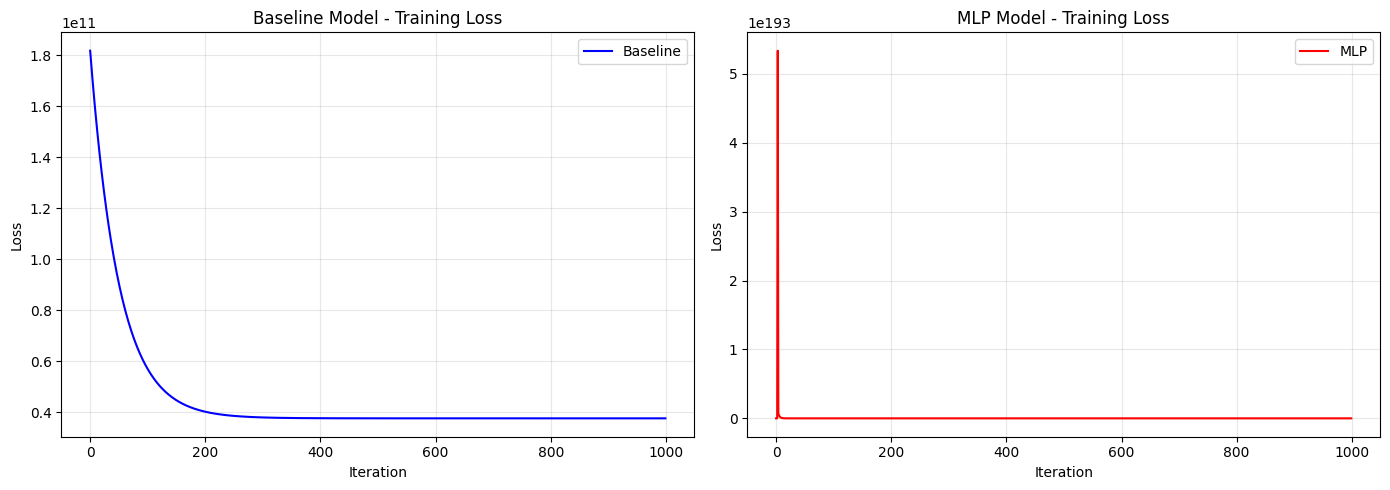

In [ ]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

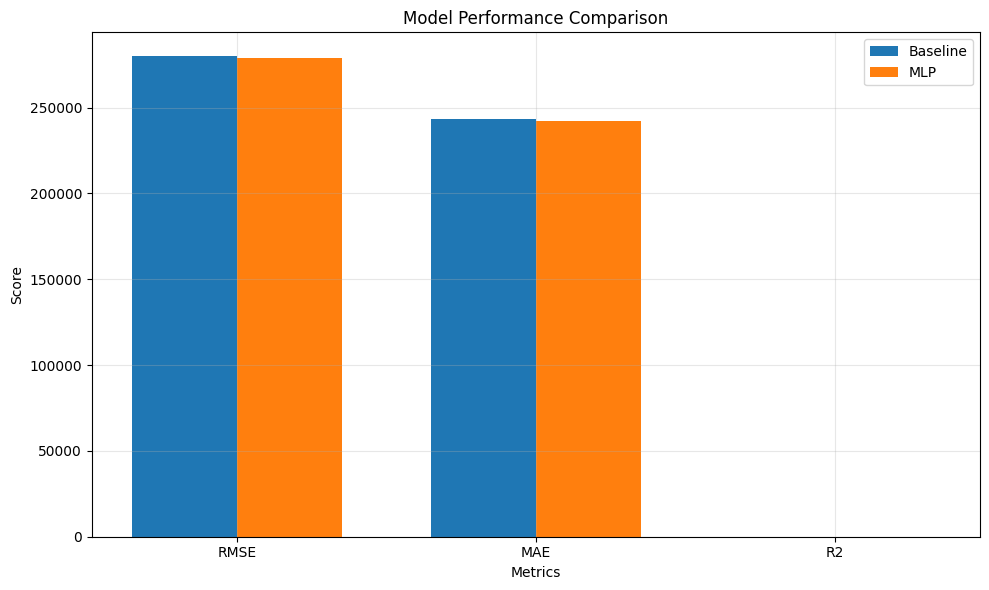

In [ ]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

# Metrics to compare
metrics = ['RMSE', 'MAE', 'R2']
baseline_scores = [baseline_metrics[m] for m in metrics]
mlp_scores = [mlp_metrics[m] for m in metrics]


x = np.arange(len(metrics))
width = 0.35

x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

In [ ]:
analysis_text = """
This experiment compared a baseline linear regression model with a multi-layer perceptron (MLP)
for a house price prediction task using a dataset of 2,000 samples and 12 features.
The primary evaluation metric was Root Mean Square Error (RMSE), as it penalizes large prediction errors and
is expressed in the same unit as house prices, making it practically interpretable.
Large loss values are expected due to the high monetary scale of house prices

1. Model performance comparison:
The MLP model performed slightly better than the baseline linear regression model across all regression metrics.
The baseline model achieved a test RMSE of approximately 279,862 and an MAE of about 243,248, while the MLP reduced the RMSE
to around 279,024 and the MAE to approximately 242,480. Although the absolute improvement is modest, it is consistent
across MSE, RMSE, MAE, and R². The R² score improved from -0.0067 for the baseline to -0.0007 for the MLP, indicating
that the neural network explained slightly more variance in house prices.

2. Reason for performance difference:
The MLP outperformed the linear model because it can capture non-linear relationships between input features
and house prices using hidden layers and ReLU activations. In contrast, linear regression assumes a strictly linear relationship,
which is often insufficient for complex real-world data such as housing markets. However, the improvement was limited due
to relatively simple network architecture, noisy features, and minimal feature engineering.

3. Computational cost:
The baseline model trained significantly faster, completing training in approximately 1 seconds.
In comparison, the MLP required around 6 seconds to train. This highlights the higher computational cost of neural networks
due to multiple layers, forward propagation, and backpropagation.

4. Challenges and surprising findings:
A key challenge was training instability in the MLP. With default hyperparameters, the loss sometimes increased during training,
requiring careful tuning of the learning rate to achieve stable convergence. Another notable finding was that despite its complexity,
the MLP did not dramatically outperform the linear model.

5. Insights gained:
This experiment demonstrates that neural networks are more flexible and expressive than linear models, but they do not automatically
guarantee large performance gains. Proper hyperparameter tuning, feature scaling, and richer feature engineering are essential.
In some scenarios, especially with limited data or weak features, simpler linear models can perform competitively while being
far more computationally efficient.
"""